In [2]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))

# my utils
from utils import preprocess_listings

LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}



In [3]:
df=pd.read_csv("../data_processed\listings_tactics_bio_vis-paris_london-2306_2406.csv")
print(df.shape)

C:\Users\yeliu\AppData\Local\Temp\ipykernel_18024\824130203.py:1: DtypeWarning: Columns (68) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("../data_processed\listings_tactics_bio_vis-paris_london-2306_2406.csv")


(187851, 124)


In [4]:
df.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [ ]:
tactics_bio=["ouverture", "authenticité","sociabilité","auto_promotion","exemplarité"]
tactic_pic=["host_picture_type","is_smiling"]


## desc

In [ ]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import group_mean_table_ttest


cols_to_check=[
    "booking_rate_l90d","availability_90","number_of_reviews_ltm", 
    "review_scores_rating", "years_since_host","price", 
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité",
    "is_smiling" 
    ]

x_vars=["host_identity_verified", "host_has_profile_pic",         
    "review_scores_rating", #"has_rating", "number_of_reviews",
    "years_since_host","professional_host",'host_is_superhost', ##'calculated_host_listings_count',
    # 'status_changed', 'old_host_sp_changed',# "is_changed"
    "lang", "len",
    "price",
    "availability_90",#*
    "room_type", "instant_bookable", #'is_within_1km',
    "ouverture", "authenticité","sociabilité","auto_promotion","exemplarité", 
    "host_picture_type","is_smiling"
]  

df_ttest=df[df['in_2024']==0]# pre-treatement balance test（jo冲击之前两地数据是否存在差异）
group_mean_table_ttest(df_ttest, cols_to_check=cols_to_check, 
                       group_col="in_paris",
                       save=False, output_folder="mod_results", filename_noext=None)

## paris, london本身存在差异，要引入一个level comparison，要求两个城市的变化趋势平行


[CHECK] ttest takes only 2 groups! OR go to ANOVA!
[INFO] groups :0 vs 1
[INFO] ttest on 75257 lines.

[CHECK] ttest take ONLY numeric cols! 



in_paris,0,1,ttest_p,significance
proportion,0.562818,0.437182,NaN,NaN
booking_rate_l90d,0.162585,0.213811,0.0,***
availability_90,45.539711,39.167867,0.0,***
number_of_reviews_ltm,9.216782,11.081548,0.0,***
review_scores_rating,4.695801,4.70252,0.04753,*
years_since_host,7.062329,7.423665,0.0,***
price,226.773609,246.315462,0.000001,***
ouverture,-0.181129,-0.177168,0.677507,
authenticité,-0.35052,-0.344988,0.583594,
sociabilité,-0.112009,-0.102372,0.334853,


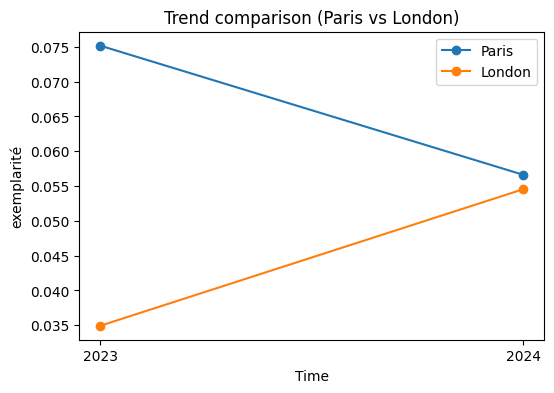

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
col=""

# 按城市+时间求均值
trend = df.groupby(["in_paris", "in_2024"])[col].mean().reset_index()
# 拆成两条线
paris = trend[trend["in_paris"] == 1]
london = trend[trend["in_paris"] == 0]

plt.figure(figsize=(6,4))

plt.plot(paris["in_2024"], paris[col], marker='o', label="Paris")
plt.plot(london["in_2024"], london[col], marker='o', label="London")

plt.xticks([0,1], ["2023", "2024"])
plt.xlabel("Time")
plt.ylabel(f"{col}")
plt.title("Trend comparison (Paris vs London)")
plt.legend()

plt.show()

In [69]:
import statsmodels.formula.api as smf

model = smf.ols(
    "auto_promotion ~ in_paris + in_2024 + in_paris:in_2024",
    data=df
).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         auto_promotion   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     195.7
Date:                Mon, 30 Mar 2026   Prob (F-statistic):          1.71e-126
Time:                        15:16:20   Log-Likelihood:            -1.3069e+05
No. Observations:               92339   AIC:                         2.614e+05
Df Residuals:                   92335   BIC:                         2.614e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.3391      0.007  

In [ ]:
from scipy import stats
import pandas as pd

df["group"] = (
    df["in_paris"].astype(str) + "_" + df["in_2024"].astype(str)
)
groups = df["group"].astype(str).unique()

def ttest(a, b):
    return stats.ttest_ind(a.dropna(), b.dropna()).pvalue



tactics = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
    # "host_picture_type",
    "is_smiling"
]

controls=[
    "booking_rate_l90d","availability_90","number_of_reviews_ltm", 
    "review_scores_rating", "years_since_host","price",   
    ]


table = []
for var in controls + tactics:
    row = {"variable numérique: mean(std)": var}
    
    for g in groups:
        # print(g)
        
        sub = df[df["group"] == g][var]    
        city="paris" if g.split("_")[0]=="1" else "london"
        time="2024" if  g.split("_")[1]=="1" else "2023"
        row[f"{city} {time}"] = f"{sub.mean():.2f} ({sub.std():.2f})"
        
    table.append(row)

table1 = pd.DataFrame(table)
table1

,variable numérique: mean(std),london 2023,london 2024,paris 2023,paris 2024
0,booking_rate_l90d,0.16 (0.27),0.12 (0.22),0.21 (0.31),0.08 (0.16)
1,availability_90,45.54 (28.53),50.27 (27.62),39.17 (27.22),49.92 (25.13)
2,number_of_reviews_ltm,9.22 (15.95),8.62 (14.82),11.08 (18.69),7.33 (13.90)
3,review_scores_rating,4.70 (0.49),4.73 (0.39),4.70 (0.44),4.78 (0.31)
4,years_since_host,7.06 (3.32),6.40 (3.68),7.42 (3.38),6.84 (3.76)
5,price,226.77 (527.16),211.02 (876.68),246.32 (570.70),283.36 (682.86)
6,ouverture,-0.18 (0.92),-0.18 (0.91),-0.18 (0.93),-0.19 (0.93)
7,authenticité,-0.35 (0.99),-0.43 (1.01),-0.34 (0.97),-0.35 (0.98)
8,sociabilité,-0.11 (0.99),-0.16 (0.98),-0.10 (0.96),-0.15 (0.96)
9,auto_promotion,0.34 (1.03),0.41 (1.01),0.20 (0.97),0.24 (0.97)


[INFO] groups: ['0_0' '0_1' '1_0' '1_1']


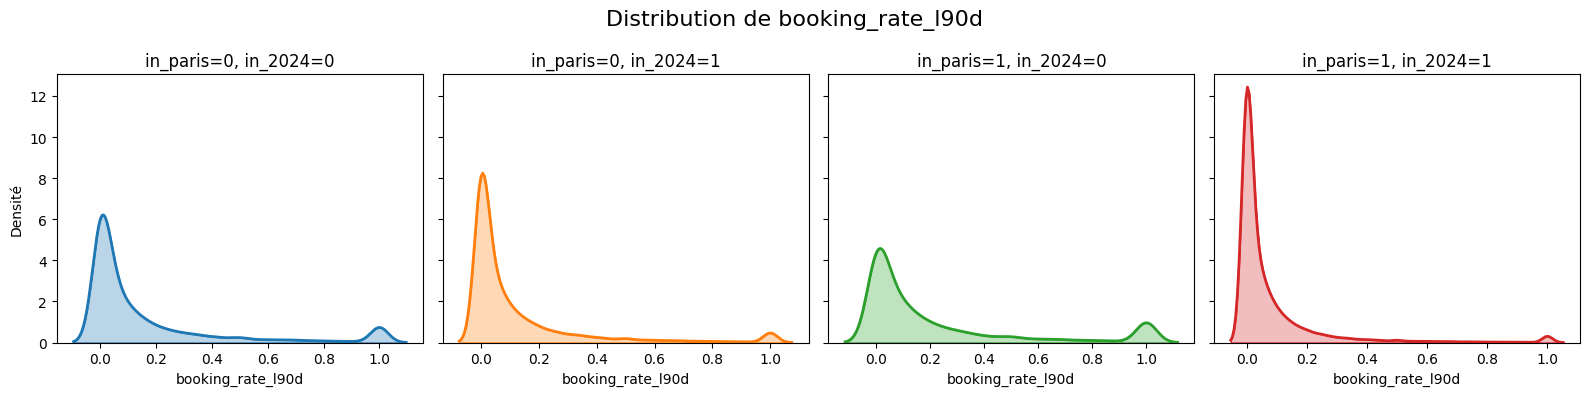

In [39]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import plot_distribution
plot_distribution(
    df, 
    group_cols=['in_paris','in_2024'], 
    y_var='booking_rate_l90d',
    save=False, 
    output_folder="mod_results",
    filename=None)

In [43]:
df[tactics_bio].describe()

,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
count,92339.000000,92339.000000,92339.000000,92339.000000,92339.000000
mean,-0.182682,-0.372649,-0.135705,0.307224,0.053699
std,0.921622,0.991799,0.973321,0.999546,0.951822
min,-1.899298,-2.072260,-2.165260,-1.688499,-0.861799
25%,-0.984279,-1.332886,-1.039574,-0.624391,-0.612170
50%,-0.263486,-0.451861,0.032526,0.520209,-0.421510
75%,0.582050,0.515467,0.742395,1.189415,0.407699
max,1.793152,1.793233,1.518248,1.878054,2.876670


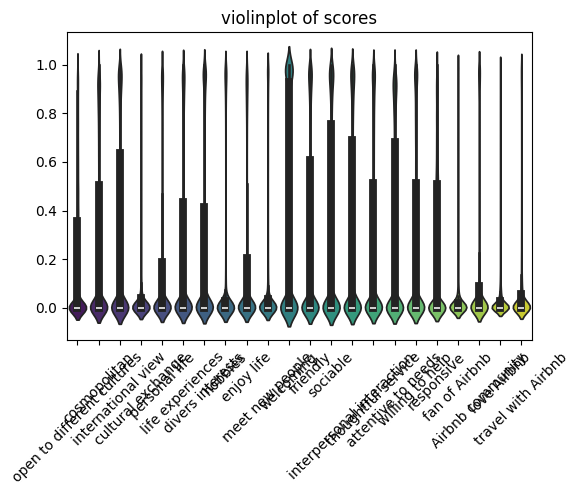

In [42]:
importlib.reload(preprocess_listings)
from utils.preprocess_listings import plot_violon

plot_violon(df_input=df, vars=LABELS_EN, to_fillna0=True, save=False, output_folder="../output_mod", filename="violon_tactics_weighted.jpg")
